Construir un
modelo que pueda pronosticar el valor de la prima de un asegurado con un MAPE menor o igual al
15% (charges)

In [2]:
import pandas as pd
import numpy as np
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
warnings.filterwarnings("ignore")
data = pd.read_csv('datos_caso_3.csv')
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


No hay datos nulos

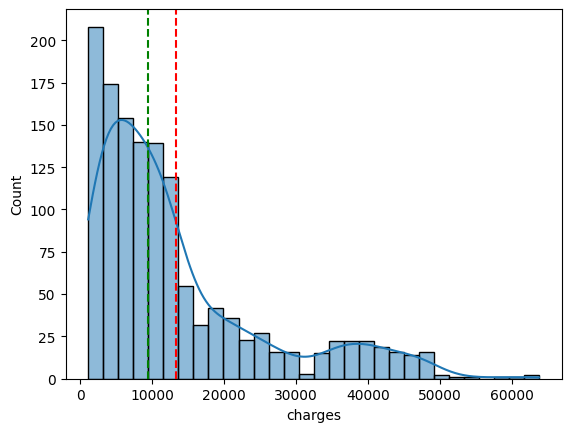

In [4]:
import matplotlib.pyplot as plt
import seaborn as sb
sb.histplot(data= data, x='charges', kde=True)
plt.axvline(x= data.charges.mean(), color='red', linestyle='dashed')
plt.axvline(x= data.charges.median(), color='green', linestyle='dashed')
plt.show()

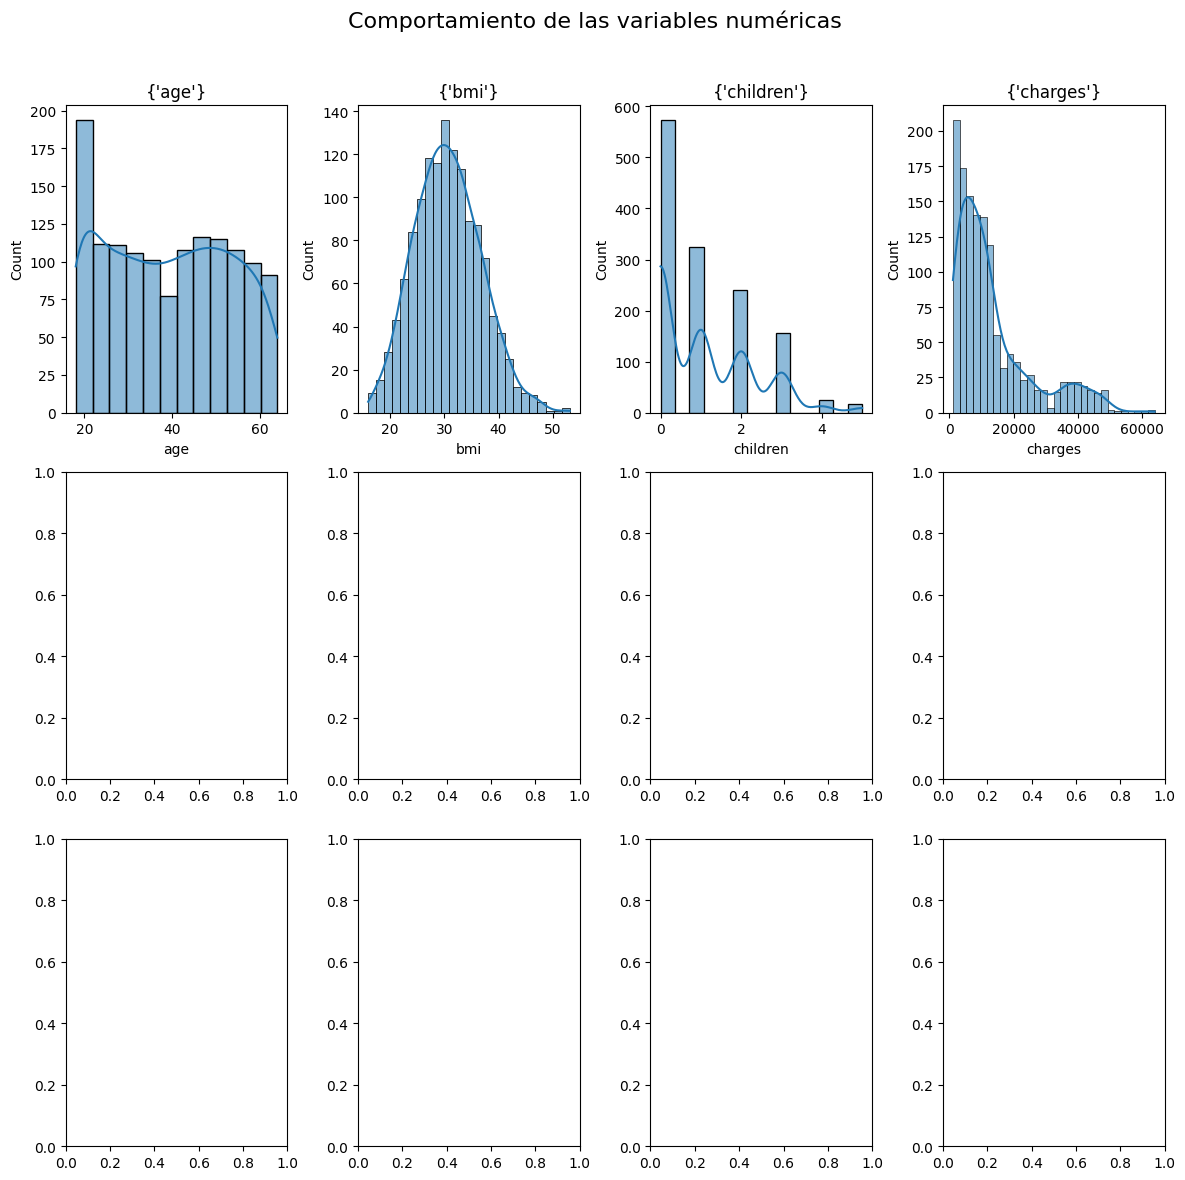

In [5]:
# Histogramas de frecuencias
fig, ax = plt.subplots(3, 4, figsize=(12, 12))
ax = ax.flat
num_col = data.select_dtypes(include = ['float64', 'int64'] ).columns
for i, col in enumerate(num_col):
    sb.histplot(data=data, x=col, kde=True, ax=ax[i])
    ax[i].set_title({col})
fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.suptitle('Comportamiento de las variables numéricas', fontsize=16)
plt.show()

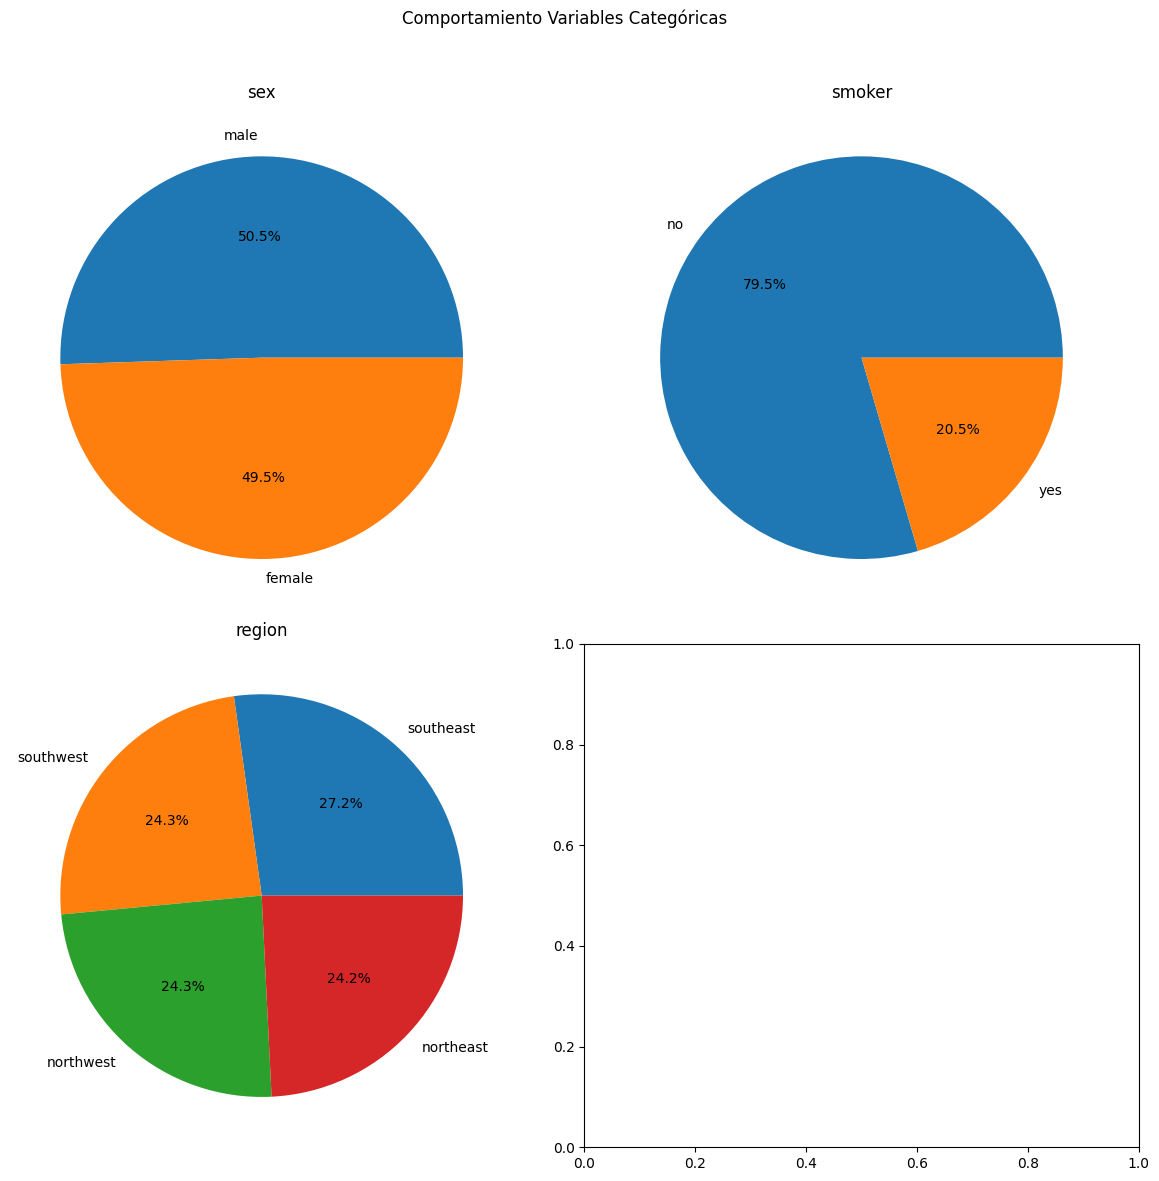

In [6]:
##GRÁFICOS DE TORTA
fig, ax = plt.subplots(2, 2, figsize = (12, 12))
ax = ax.flat
cat_col = data.select_dtypes(include = ['object']).columns
for i, col in enumerate(cat_col):
    ax[i].pie(x = data[col].value_counts(), labels = data[col].value_counts().index, autopct = '%0.1f%%')
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle("Comportamiento Variables Categóricas")
plt.show()

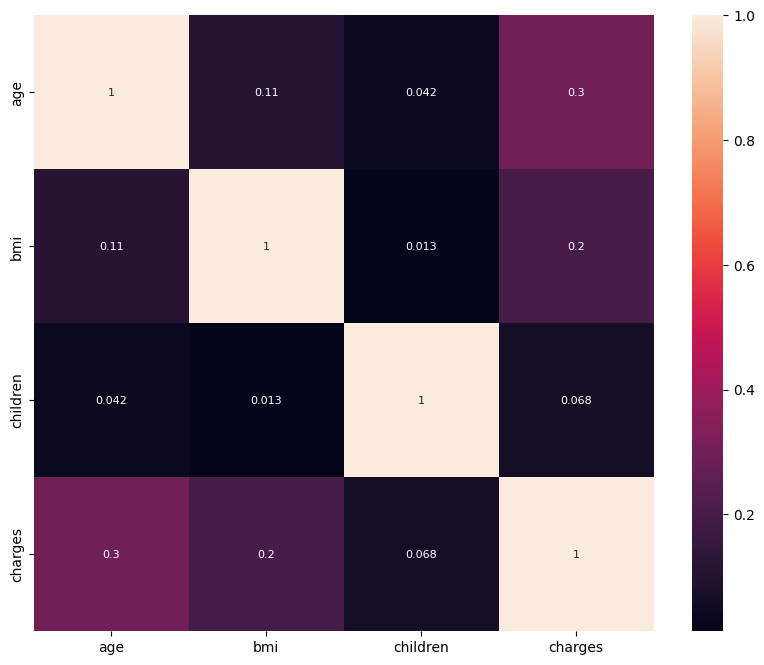

In [7]:
plt.figure(figsize=(10,8))
sb.heatmap(data.corr(numeric_only=True), annot=True, annot_kws={"size": 8})
plt.show()

# **Preparación de los datos**

In [8]:
import sklearn 
categorical_cols = data.select_dtypes(include='object').columns
categorical_transformer = sklearn.compose.make_column_transformer((sklearn.preprocessing.OrdinalEncoder(), categorical_cols), remainder='passthrough')
categorical_transformer

,transformers,"[('ordinalencoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'


In [9]:
data_transformed = pd.DataFrame(categorical_transformer.fit_transform(data), 
                                 columns=categorical_transformer.get_feature_names_out(),
                                 index=data.index).rename(columns= lambda x: x.removeprefix('ordinalencoder__')).rename(columns= lambda x: x.removeprefix('remainder__'))
data_transformed.head()

,sex,smoker,region,age,bmi,children,charges
0,0.0,1.0,3.0,19.0,27.900,0.0,16884.92400
1,1.0,0.0,2.0,18.0,33.770,1.0,1725.55230
2,1.0,0.0,2.0,28.0,33.000,3.0,4449.46200
3,1.0,0.0,1.0,33.0,22.705,0.0,21984.47061
4,1.0,0.0,1.0,32.0,28.880,0.0,3866.85520


In [10]:
#prerocesamiento

from sklearn.compose import ColumnTransformer as columnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline

num_col = data.select_dtypes(include=['int64', 'float64']).columns.to_list()
cat_col = data.select_dtypes(include=['object']).columns.to_list()

num_transformer = Pipeline(steps=[('scaler', MinMaxScaler())])
cat_transformer = Pipeline(steps=[('encoder', OneHotEncoder())])

preprocessor = columnTransformer(transformers=[('num', num_transformer, num_col),
                                                ('cat', cat_transformer, cat_col)], remainder='passthrough')

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,feature_range,"(0, ...)"
,copy,True
,clip,False


In [11]:
data_pre = preprocessor.fit_transform(data)
cod_cat = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_col)
label = np.concatenate((num_col, cod_cat))
data_pro = pd.DataFrame(data_pre, columns=label)
data_pro.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,0.021739,0.321227,0.0,0.251611,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.000000,0.479150,0.2,0.009636,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.217391,0.458434,0.6,0.053115,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.326087,0.181464,0.0,0.333010,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.304348,0.347592,0.0,0.043816,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


In [12]:
#eliminar variable objetivo

x = data_pro.drop('charges', axis=1)
y = data_pro[['charges' ]]

El tamaño del conjunto de entrenamiento es: (401, 11)
Y el tamaño del conjunto de validación es: (937, 11)


<Axes: xlabel='charges', ylabel='Count'>

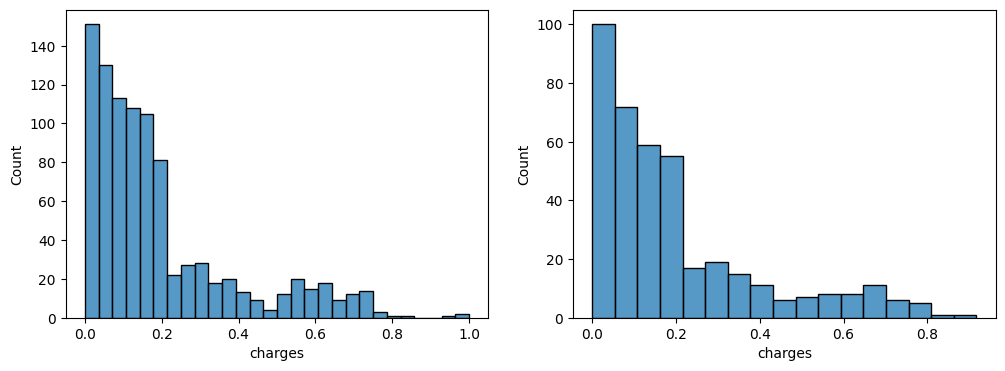

In [13]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.7, random_state=123)
print(f'El tamaño del conjunto de entrenamiento es: {x_train.shape}\nY el tamaño del conjunto de validación es: {x_test.shape}')
fig, ax = plt.subplots(1,2, figsize=(12,4))
sb.histplot(data = y_test, x='charges', ax = ax[0])
sb.histplot(data = y_train, x='charges', ax = ax[1])


In [14]:
# Regresión lineal
modelo_1 = LinearRegression()
modelo_1.fit(x_train, y_train)
modelo_1.coef_


array([[ 0.18152455,  0.24378779,  0.02183742,  0.00323495, -0.00323495,
        -0.18477517,  0.18477517,  0.00822192,  0.00804215, -0.01054098,
        -0.00572309]])

In [15]:
modelo_1.intercept_

array([0.11733013])

Las métricas de desemepeño en entrenamiento para la regresión lienal son:
R2: 0.7425426724462072
RMSE: 0.10013320261693442
MAE: 0.07107799427141406
MAPE: 378147569471.1677


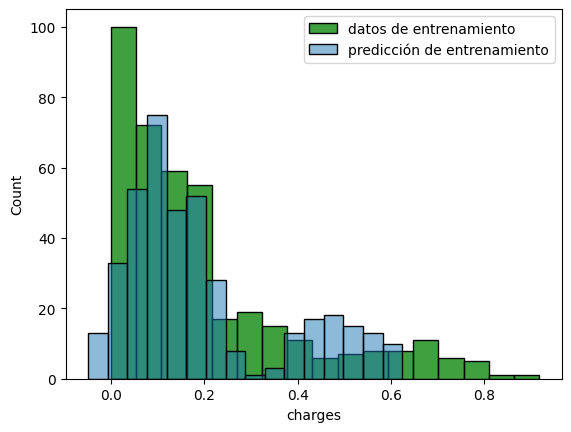

In [18]:
pred_train_1 = modelo_1.predict(x_train)
pred_test_1 = modelo_1.predict(x_test)
# vamos a desescalar nuestras variables para obtener los valores reales
pred_train_des_1 = pred_train_1 * (np.max(y) - np.min(y)) + np.min(y)
pred_test_des_1 = pred_test_1 * (np.max(y) - np.min(y)) + np.min(y)
y_train_des = y_train * (np.max(y) - np.min(y)) + np.min(y)
y_test_des = y_test * (np.max(y) - np.min(y)) + np.min(y)
r2_train_1 = r2_score(y_train_des, pred_train_des_1)
rmse_train_1 = root_mean_squared_error(y_train_des, pred_train_des_1)
mae_train_1 = mean_absolute_error(y_train_des, pred_train_des_1)
mape_train_1 = mean_absolute_percentage_error(y_train_des, pred_train_des_1)
print(f'Las métricas de desemepeño en entrenamiento para la regresión lienal son:\nR2: {r2_train_1}\nRMSE: {rmse_train_1}\nMAE: {mae_train_1}\nMAPE: {mape_train_1}')
sb.histplot(data= y_train_des, x= 'charges',color='green', label='datos de entrenamiento')
sb.histplot(pred_train_des_1, label='predicción de entrenamiento')
plt.legend()
plt.show()

Las métricas de desemepeño en entrenamiento para la regresión lienal son:
R2: 0.7511166101968897
RMSE: 0.09550051225141958
MAE: 0.0682067279837222
MAPE: 1.77771016806758


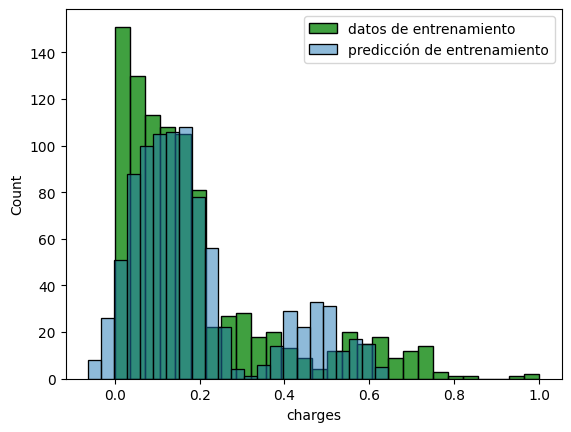

In [ ]:
r2_test_1 = r2_score(y_test_des, pred_test_des_1)
rmse_test_1 = root_mean_squared_error(y_test_des, pred_test_des_1)
mae_test_1 = mean_absolute_error(y_test_des, pred_test_des_1)
mape_test_1 = mean_absolute_percentage_error(y_test_des, pred_test_des_1)
print(f'Las métricas de desemepeño en entrenamiento para la regresión lineal son:\nR2: {r2_test_1}\nRMSE: {rmse_test_1}\nMAE: {mae_test_1}\nMAPE: {mape_test_1}')
sb.histplot(data= y_test_des, x= 'charges',color='green', label='datos de entrenamiento')
sb.histplot(pred_test_des_1, label='predicción de entrenamiento')
plt.legend()
plt.show()

El modelo no es capaz de capturar un ~25% de los datos,
No hay outliers muy grandes,
El mape no funciono (y_train_des muy cercano a cero en promedio)


In [45]:
# KNN
modelo_2 = KNeighborsRegressor()
param_grid = {'n_neighbors': list(range(1, 200)),
              'p':[1,2]}
reg_2 = GridSearchCV(estimator= modelo_2, param_grid= param_grid, cv=3, scoring='neg_mean_absolute_percentage_error')
reg_2.fit(x_train, y_train)
validation = pd.concat([pd.DataFrame(reg_2.cv_results_['params']),
                        pd.DataFrame(reg_2.cv_results_['mean_test_score'], columns=['MAPE'])], axis=1)
validation.sort_values('MAPE', ascending=False)

,n_neighbors,p,MAPE
1,1,2,-1.735497e+09
0,1,1,-1.735497e+09
2,2,1,-2.272675e+09
3,2,2,-2.272675e+09
4,3,1,-5.346691e+10
...,...,...,...
394,198,1,-1.800806e+12
391,196,2,-1.803274e+12
389,195,2,-1.806515e+12
387,194,2,-1.810430e+12


Tampoco cumple

Las métricas de desemepeño en entrenamiento para KHH:
R2: 1.0
RMSE: 0.0
MAE: 0.0
MAPE: 0.0


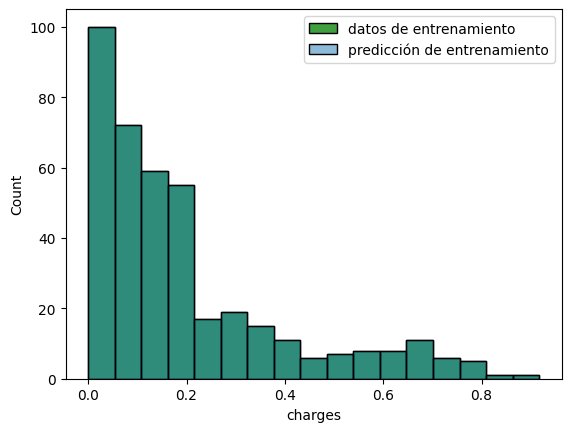

In [46]:
modelo_2_final= reg_2.best_estimator_


pred_train_2 = modelo_2_final.predict(x_train)
pred_test_2 = modelo_2_final.predict(x_test)
#Desescalar
pred_train_des_2 = pred_train_2 * (np.max(y) - np.min(y)) + np.min(y)
pred_test_des_2 = pred_test_2 * (np.max(y) - np.min(y)) + np.min(y)
y_train_des = y_train * (np.max(y) - np.min(y)) + np.min(y)
y_test_des = y_test * (np.max(y) - np.min(y)) + np.min(y)
r2_train_2 = r2_score(y_train_des, pred_train_des_2)
rmse_train_2 = root_mean_squared_error(y_train_des, pred_train_des_2)
mae_train_2 = mean_absolute_error(y_train_des, pred_train_des_2)
mape_train_2 = mean_absolute_percentage_error(y_train_des, pred_train_des_2)
print(f'Las métricas de desemepeño en entrenamiento para KHH:\nR2: {r2_train_2}\nRMSE: {rmse_train_2}\nMAE: {mae_train_2}\nMAPE: {mape_train_2}')
sb.histplot(data= y_train_des, x= 'charges',color='green', label='datos de entrenamiento')
sb.histplot(pred_train_des_2, label='predicción de entrenamiento')
plt.legend()
plt.show()

Tampoco

Las métricas de desemepeño en prueba para KNN son:
R2: 0.6354006598793522
RMSE: 0.11558878098006059
MAE: 0.06209090750811165
MAPE: 0.4191341288645729


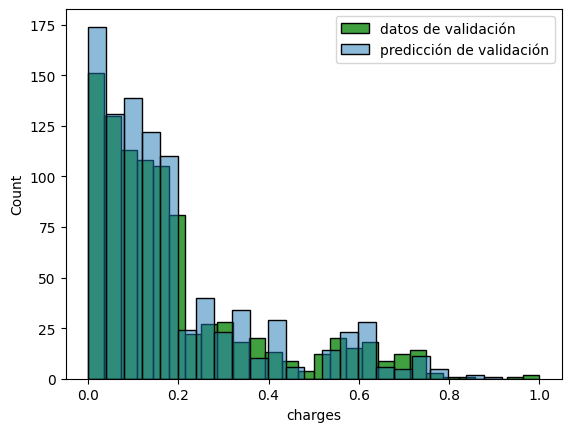

In [47]:
r2_test_2 = r2_score(y_test_des, pred_test_des_2)
rmse_test_2 = root_mean_squared_error(y_test_des, pred_test_des_2)
mae_test_2 = mean_absolute_error(y_test_des, pred_test_des_2)
mape_test_2 = mean_absolute_percentage_error(y_test_des, pred_test_des_2)
print(f'Las métricas de desemepeño en prueba para KNN son:\nR2: {r2_test_2}\nRMSE: {rmse_test_2}\nMAE: {mae_test_2}\nMAPE: {mape_test_2}')
sb.histplot(data= y_test_des, x= 'charges',color='green', label='datos de validación')
sb.histplot(pred_test_des_2, label='predicción de validación')
plt.legend()
plt.show()

No cumple

In [48]:
#Maquinas de Soporte Vectorial
modelo_3 = SVR()

param_grid = {'C': [0, 0.01, 1, 10, 100], 'kernel': ['linear', 'poly', 'rbf'],'degree':[2,3]}
reg_3 = GridSearchCV(estimator= modelo_3, param_grid= param_grid, cv=3, scoring='neg_mean_absolute_percentage_error')
reg_3.fit(x_train, y_train)
validation = pd.concat([pd.DataFrame(reg_3.cv_results_['params']),
                        pd.DataFrame(reg_3.cv_results_['mean_test_score'], columns=['MAPE'])], axis=1)
validation.sort_values('MAPE', ascending=False)

,C,degree,kernel,MAPE
29,100.00,3,rbf,-2.484346e+11
26,100.00,2,rbf,-2.484346e+11
28,100.00,3,poly,-6.407678e+11
21,10.00,3,linear,-6.512853e+11
18,10.00,2,linear,-6.512853e+11
24,100.00,2,linear,-6.562992e+11
27,100.00,3,linear,-6.562992e+11
12,1.00,2,linear,-6.578051e+11
15,1.00,3,linear,-6.578051e+11
22,10.00,3,poly,-1.025671e+12


In [49]:
modelo_3_final= reg_3.best_estimator_
modelo_3_final

,kernel,'rbf'
,degree,2
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,100
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


Las métricas de desempeño en entrenamiento MSV son:
R2: 0.845870445642608
RMSE: 0.07747622283345691
MAE: 0.06720575851830443
MAPE: 91353500269.22826


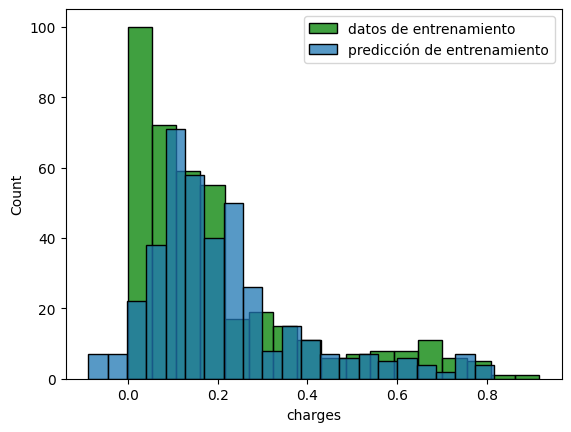

In [50]:
pred_train_3 = modelo_3_final.predict(x_train)
pred_test_3 = modelo_3_final.predict(x_test)
# vamos a desescalar nuestras variables para obtener los valores reales
pred_train_des_3 = pred_train_3 * (np.max(y) - np.min(y)) + np.min(y)
pred_test_des_3 = pred_test_3 * (np.max(y) - np.min(y)) + np.min(y)
y_train_des = y_train * (np.max(y) - np.min(y)) + np.min(y)
y_test_des = y_test * (np.max(y) - np.min(y)) + np.min(y)
r2_train_3 = r2_score(y_train_des, pred_train_des_3)
rmse_train_3 = root_mean_squared_error(y_train_des, pred_train_des_3)
mae_train_3 = mean_absolute_error(y_train_des, pred_train_des_3)
mape_train_3 = mean_absolute_percentage_error(y_train_des, pred_train_des_3)
print(f'Las métricas de desempeño en entrenamiento MSV son:\nR2: {r2_train_3}\nRMSE: {rmse_train_3}\nMAE: {mae_train_3}\nMAPE: {mape_train_3}')
sb.histplot(data= y_train_des, x= 'charges',color='green', label='datos de entrenamiento')
sb.histplot(pred_train_des_3, label='predicción de entrenamiento')
plt.legend()
plt.show()

Las métricas de desemepeño en entrenamiento para MSV son:
R3: 0.6385762982462171
RMSE: 0.11508429439364293
MAE: 0.08799901179616973
MAPE: 2.979309190628465


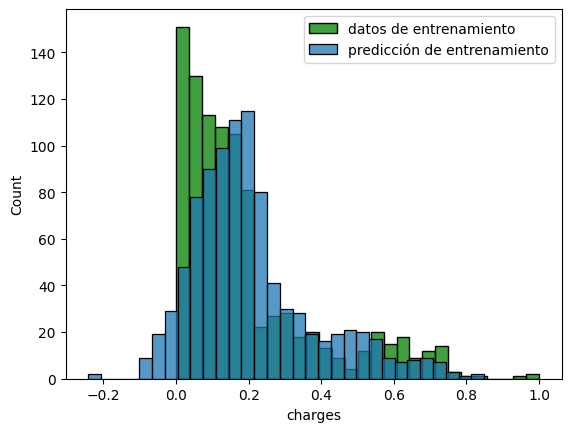

In [51]:
r2_test_3 = r2_score(y_test_des, pred_test_des_3)
rmse_test_3 = root_mean_squared_error(y_test_des, pred_test_des_3)
mae_test_3 = mean_absolute_error(y_test_des, pred_test_des_3)
mape_test_3 = mean_absolute_percentage_error(y_test_des, pred_test_des_3)
print(f'Las métricas de desemepeño en entrenamiento para MSV son:\nR3: {r2_test_3}\nRMSE: {rmse_test_3}\nMAE: {mae_test_3}\nMAPE: {mape_test_3}')
sb.histplot(data= y_test_des, x= 'charges',color='green', label='datos de entrenamiento')
sb.histplot(pred_test_des_3, label='predicción de entrenamiento')
plt.legend()
plt.show()

In [52]:
#Arboles de Decisión

modelo_4 = DecisionTreeRegressor()
param_grid = {'criterion' : ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
              'max_depth': [None], 'min_samples_split': [2,3], 'max_leaf_nodes': [None]}
reg_4 = GridSearchCV(estimator= modelo_4, param_grid= param_grid, cv=3, scoring='neg_mean_absolute_percentage_error')
reg_4.fit(x_train, y_train)
validation = pd.concat([pd.DataFrame(reg_4.cv_results_['params']),
                        pd.DataFrame(reg_4.cv_results_['mean_test_score'], columns=['MAPE'])], axis=1)
validation.sort_values('MAPE', ascending=False)

,criterion,max_depth,max_leaf_nodes,min_samples_split,MAPE
6,poisson,None,None,2,-1.735497e+09
0,squared_error,None,None,2,-1.735497e+09
2,friedman_mse,None,None,2,-1.735497e+09
3,friedman_mse,None,None,3,-2.272675e+09
7,poisson,None,None,3,-2.272675e+09
1,squared_error,None,None,3,-2.272675e+09
5,absolute_error,None,None,3,-2.272675e+09
4,absolute_error,None,None,2,-9.127218e+10


In [53]:
modelo_4_final= reg_4.best_estimator_
modelo_4_final

,criterion,'poisson'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


Las métricas de desemepeño en entrenamiento para DT son:
R4: 0.9999999992430824
RMSE: 5.429374495807836e-06
MAE: 3.8343575684796146e-07
MAPE: 863420565.8317486


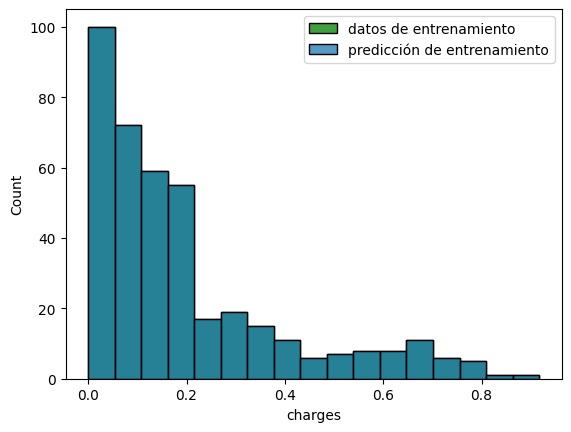

In [55]:
pred_train_4 = modelo_4_final.predict(x_train)
pred_test_4 = modelo_4_final.predict(x_test)
# vamos a desescalar nuestras variables para obtener los valores reales
pred_train_des_4 = pred_train_4 * (np.max(y) - np.min(y)) + np.min(y)
pred_test_des_4 = pred_test_4 * (np.max(y) - np.min(y)) + np.min(y)
y_train_des = y_train * (np.max(y) - np.min(y)) + np.min(y)
y_test_des = y_test * (np.max(y) - np.min(y)) + np.min(y)
r2_train_4 = r2_score(y_train_des, pred_train_des_4)
rmse_train_4 = root_mean_squared_error(y_train_des, pred_train_des_4)
mae_train_4 = mean_absolute_error(y_train_des, pred_train_des_4)
mape_train_4 = mean_absolute_percentage_error(y_train_des, pred_train_des_4)
print(f'Las métricas de desemepeño en entrenamiento para DT son:\nR4: {r2_train_4}\nRMSE: {rmse_train_4}\nMAE: {mae_train_4}\nMAPE: {mape_train_4}')
sb.histplot(data= y_train_des, x= 'charges',color='green', label='datos de entrenamiento')
sb.histplot(pred_train_des_4, label='predicción de entrenamiento')
plt.legend()
plt.show()

Las métricas de desemepeño en entrenamiento para DT son:
R4: 0.7156108236327803
RMSE: 0.10208555076248128
MAE: 0.048557585864863445
MAPE: 0.5873798941388347


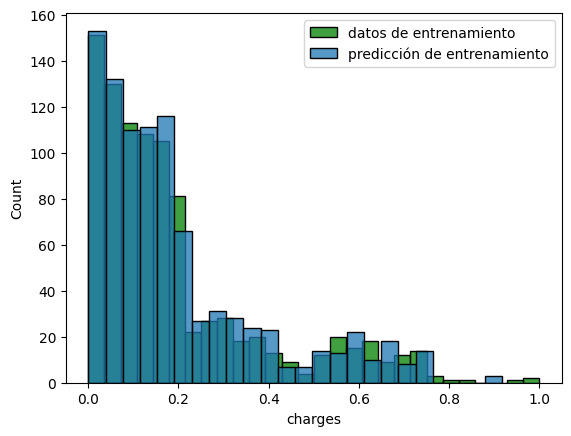

In [57]:
r2_test_4 = r2_score(y_test_des, pred_test_des_4)
rmse_test_4 = root_mean_squared_error(y_test_des, pred_test_des_4)
mae_test_4 = mean_absolute_error(y_test_des, pred_test_des_4)
mape_test_4 = mean_absolute_percentage_error(y_test_des, pred_test_des_4)
print(f'Las métricas de desemepeño en entrenamiento para DT son:\nR4: {r2_test_4}\nRMSE: {rmse_test_4}\nMAE: {mae_test_4}\nMAPE: {mape_test_4}')
sb.histplot(data= y_test_des, x= 'charges',color='green', label='datos de entrenamiento')
sb.histplot(pred_test_des_4, label='predicción de entrenamiento')
plt.legend()
plt.show()

In [58]:
#BOsque aleatorio

modelo_5 = RandomForestRegressor(random_state=123)

param_grid = {'criterion' : [ 'friedman_mse', 'poisson', 'squared_error','absolute_error'],
              'max_depth': [None,5,6,3,4,10,100], 'max_leaf_nodes': [2,3,4,None],'n_estimators': [100,200,300]}
reg_5 = GridSearchCV(estimator= modelo_5, param_grid= param_grid, cv=3, scoring='neg_mean_absolute_percentage_error')
reg_5.fit(x_train, y_train)
validation = pd.concat([pd.DataFrame(reg_5.cv_results_['params']),
                        pd.DataFrame(reg_5.cv_results_['mean_test_score'], columns=['MAPE'])], axis=1)
validation.sort_values('MAPE', ascending=False)


,criterion,max_depth,max_leaf_nodes,n_estimators,MAPE
93,poisson,NaN,NaN,100,-3.907394e+10
165,poisson,100.0,NaN,100,-3.907394e+10
153,poisson,10.0,NaN,100,-3.993508e+10
94,poisson,NaN,NaN,200,-4.135936e+10
166,poisson,100.0,NaN,200,-4.135936e+10
...,...,...,...,...,...
86,poisson,NaN,2.0,300,-1.244082e+12
50,friedman_mse,4.0,2.0,300,-1.244082e+12
62,friedman_mse,10.0,2.0,300,-1.244082e+12
38,friedman_mse,3.0,2.0,300,-1.244082e+12


In [60]:
modelo_5_final =reg_5.best_estimator_

modelo_5_final

,n_estimators,100
,criterion,'poisson'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Las métricas de desemepeño en entrenamiento para RF son:
R4: 0.9766084927898943
RMSE: 0.030182456352500855
MAE: 0.01547873549474523
MAPE: 25048259888.661865


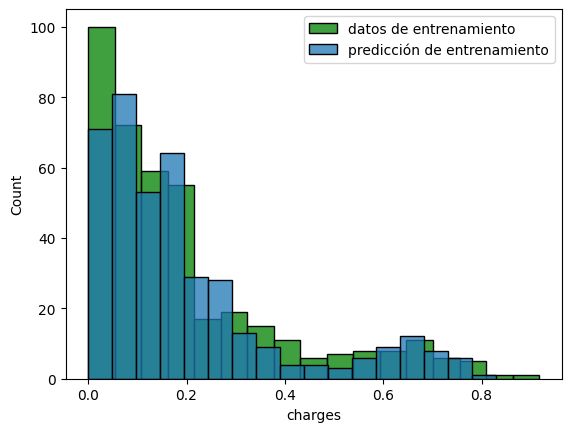

In [61]:
pred_train_5 = modelo_5_final.predict(x_train)
pred_test_5 = modelo_5_final.predict(x_test)
# vamos a desescalar nuestras variables para obtener los valores reales
pred_train_des_5 = pred_train_5 * (np.max(y) - np.min(y)) + np.min(y)
pred_test_des_5 = pred_test_5 * (np.max(y) - np.min(y)) + np.min(y)
y_train_des = y_train * (np.max(y) - np.min(y)) + np.min(y)
y_test_des = y_test * (np.max(y) - np.min(y)) + np.min(y)
r2_train_5 = r2_score(y_train_des, pred_train_des_5)
rmse_train_5 = root_mean_squared_error(y_train_des, pred_train_des_5)
mae_train_5 = mean_absolute_error(y_train_des, pred_train_des_5)
mape_train_5 = mean_absolute_percentage_error(y_train_des, pred_train_des_5)
print(f'Las métricas de desemepeño en entrenamiento para RF son:\nR4: {r2_train_5}\nRMSE: {rmse_train_5}\nMAE: {mae_train_5}\nMAPE: {mape_train_5}')
sb.histplot(data= y_train_des, x= 'charges',color='green', label='datos de entrenamiento')
sb.histplot(pred_train_des_5, label='predicción de entrenamiento')
plt.legend()
plt.show()

Las métricas de desemepeño en entrenamiento para RF son:
R4: 0.8437679550511072
RMSE: 0.07566461090901594
MAE: 0.04192842023859934
MAPE: 0.4815743558551555


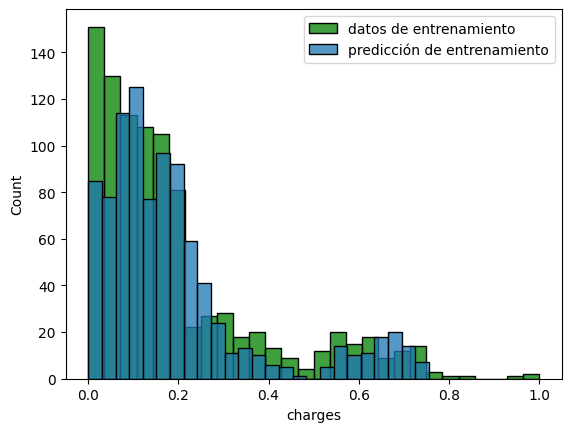

In [63]:
r2_test_5 = r2_score(y_test_des, pred_test_des_5)
rmse_test_5 = root_mean_squared_error(y_test_des, pred_test_des_5)
mae_test_5 = mean_absolute_error(y_test_des, pred_test_des_5)
mape_test_5 = mean_absolute_percentage_error(y_test_des, pred_test_des_5)
print(f'Las métricas de desemepeño en entrenamiento para RF son:\nR4: {r2_test_5}\nRMSE: {rmse_test_5}\nMAE: {mae_test_5}\nMAPE: {mape_test_5}')
sb.histplot(data= y_test_des, x= 'charges',color='green', label='datos de entrenamiento')
sb.histplot(pred_test_des_5, label='predicción de entrenamiento')
plt.legend()
plt.show()

In [64]:
#AdapBoost

modelo_6 = AdaBoostRegressor()

param_grid = {'n_estimators':[100,200,400],'loss':['linear','square','exponential'],'learning_rate':[0.001,0.1,1,10]}

reg_6 = GridSearchCV(estimator=modelo_6,param_grid=param_grid,cv=3,scoring='neg_mean_absolute_percentage_error')

reg_6.fit(x_train,y_train)

validation = pd.concat([pd.DataFrame(reg_6.cv_results_['params']),pd.DataFrame(reg_6.cv_results_['mean_test_score'],columns=['MAPE'])],axis=1)


validation.sort_values('MAPE',ascending=False)

,learning_rate,loss,n_estimators,MAPE
19,1.000,linear,200,-3.771547e+11
7,0.001,exponential,200,-4.140104e+11
6,0.001,exponential,100,-4.180508e+11
8,0.001,exponential,400,-4.240466e+11
4,0.001,square,200,-4.288535e+11
1,0.001,linear,200,-4.372808e+11
5,0.001,square,400,-4.444843e+11
0,0.001,linear,100,-4.448913e+11
2,0.001,linear,400,-4.449206e+11
3,0.001,square,100,-4.633801e+11


In [65]:
modelo_6_final =reg_6.best_estimator_

modelo_6_final

,estimator,None
,n_estimators,200
,learning_rate,1
,loss,'linear'
,random_state,None


Las métricas de desemepeño en entrenamiento para AD son:
R4: 0.8206705991658393
RMSE: 0.08357015871021013
MAE: 0.07064184860292806
MAPE: 755554717686.169


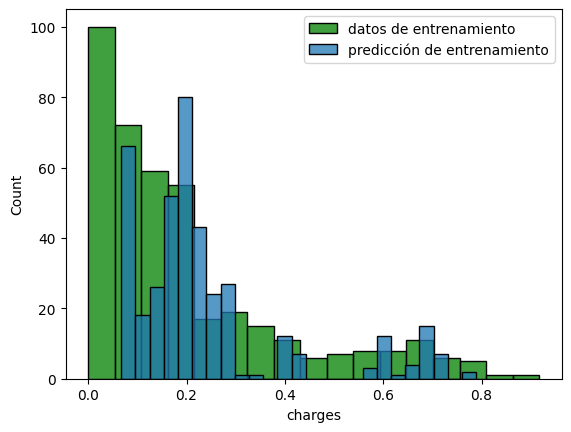

In [ ]:
pred_train_6 = modelo_6_final.predict(x_train)
pred_test_6 = modelo_6_final.predict(x_test)
# vamos a desescalar nuestras variables para obtener los valores reales
pred_train_des_6 = pred_train_6 * (np.max(y) - np.min(y)) + np.min(y)
pred_test_des_6 = pred_test_6 * (np.max(y) - np.min(y)) + np.min(y)
y_train_des = y_train * (np.max(y) - np.min(y)) + np.min(y)
y_test_des = y_test * (np.max(y) - np.min(y)) + np.min(y)
r2_train_6 = r2_score(y_train_des, pred_train_des_6)
rmse_train_6 = root_mean_squared_error(y_train_des, pred_train_des_6)
mae_train_6 = mean_absolute_error(y_train_des, pred_train_des_6)
mape_train_6 = mean_absolute_percentage_error(y_train_des, pred_train_des_6)
print(f'Las métricas de desemepeño en entrenamiento para AB son:\nR4: {r2_train_6}\nRMSE: {rmse_train_6}\nMAE: {mae_train_6}\nMAPE: {mape_train_6}')
sb.histplot(data= y_train_des, x= 'charges',color='green', label='datos de entrenamiento')
sb.histplot(pred_train_des_6, label='predicción de entrenamiento')
plt.legend()
plt.show()

Las métricas de desemepeño en entrenamiento para AB son:
R4: 0.7778204216945692
RMSE: 0.0902318399956018
MAE: 0.07543107522516683
MAPE: 2.728552797950215


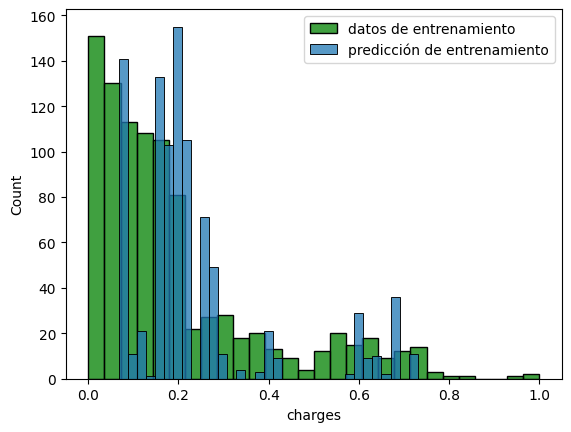

In [69]:
r2_test_6 = r2_score(y_test_des, pred_test_des_6)
rmse_test_6 = root_mean_squared_error(y_test_des, pred_test_des_6)
mae_test_6 = mean_absolute_error(y_test_des, pred_test_des_6)
mape_test_6 = mean_absolute_percentage_error(y_test_des, pred_test_des_6)
print(f'Las métricas de desemepeño en entrenamiento para AB son:\nR4: {r2_test_6}\nRMSE: {rmse_test_6}\nMAE: {mae_test_6}\nMAPE: {mape_test_6}')
sb.histplot(data= y_test_des, x= 'charges',color='green', label='datos de entrenamiento')
sb.histplot(pred_test_des_6, label='predicción de entrenamiento')
plt.legend()
plt.show()

In [73]:
#Gradient boosting grid search


modelo_7 = GradientBoostingRegressor()

param_grid = {'n_estimators':[100,200,400,500,1000],'loss':['squared_error','absolute_error'],'criterion':['friedman_mse','squared_error']}

reg_7 = GridSearchCV(estimator=modelo_7,param_grid=param_grid,cv=3,scoring='neg_mean_absolute_percentage_error')
reg_7.fit(x_train,y_train)
validation = pd.concat([pd.DataFrame(reg_7.cv_results_['params']),pd.DataFrame(reg_7.cv_results_['mean_test_score'],columns=['MAPE'])],axis=1)
validation.sort_values('MAPE',ascending=False)


,criterion,loss,n_estimators,MAPE
7,friedman_mse,absolute_error,400,-1.404611e+10
18,squared_error,absolute_error,500,-1.461333e+10
6,friedman_mse,absolute_error,200,-2.304509e+10
17,squared_error,absolute_error,400,-3.761744e+10
16,squared_error,absolute_error,200,-3.788948e+10
15,squared_error,absolute_error,100,-4.340751e+10
19,squared_error,absolute_error,1000,-5.928001e+10
5,friedman_mse,absolute_error,100,-8.335660e+10
8,friedman_mse,absolute_error,500,-9.125115e+10
9,friedman_mse,absolute_error,1000,-1.809595e+11


In [72]:
modelo_7_final =reg_7.best_estimator_
modelo_7_final

,loss,'absolute_error'
,learning_rate,0.1
,n_estimators,400
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [ ]:
pred_train_7 = modelo_7_final.predict(x_train)
pred_test_7 = modelo_7_final.predict(x_test)
# vamos a desescalar nuestras variables para obtener los valores reales
pred_train_des_7 = pred_train_7 * (np.max(y) - np.min(y)) + np.min(y)
pred_test_des_7 = pred_test_7 * (np.max(y) - np.min(y)) + np.min(y)
y_train_des = y_train * (np.max(y) - np.min(y)) + np.min(y)
y_test_des = y_test * (np.max(y) - np.min(y)) + np.min(y)
r2_train_7 = r2_score(y_train_des, pred_train_des_7)
rmse_train_7 = root_mean_squared_error(y_train_des, pred_train_des_7)
mae_train_7 = mean_absolute_error(y_train_des, pred_train_des_7)
mape_train_7 = mean_absolute_percentage_error(y_train_des, pred_train_des_7)
print(f'Las métricas de desemepeño en entrenamiento para GB son:\nR4: {r2_train_7}\nRMSE: {rmse_train_7}\nMAE: {mae_train_7}\nMAPE: {mape_train_7}')
sb.histplot(data= y_train_des, x= 'charges',color='green', label='datos de entrenamiento')
sb.histplot(pred_train_des_7, label='predicción de entrenamiento')
plt.legend()
plt.show()

In [ ]:
r2_test_7 = r2_score(y_test_des, pred_test_des_7)
rmse_test_7 = root_mean_squared_error(y_test_des, pred_test_des_7)
mae_test_7 = mean_absolute_error(y_test_des, pred_test_des_7)
mape_test_7 = mean_absolute_percentage_error(y_test_des, pred_test_des_7)
print(f'Las métricas de desemepeño en entrenamiento para la arbol de decision son:\nR4: {r2_test_7}\nRMSE: {rmse_test_7}\nMAE: {mae_test_7}\nMAPE: {mape_test_7}')
sb.histplot(data= y_test_des, x= 'actual_productivity',color='green', label='datos de validacion')
sb.histplot(pred_test_des_7, label='predicción de validacion')
plt.legend()
plt.show()

In [74]:
#Modelo 8: Red neuronal


#Perceptor multicapa


modelo_8 = MLPRegressor(random_state=123)


param_grid = {'hidden_layer_sizes': [(10,), (10,10), (10,10,10), (20,10)],
              'activation': [ 'logistic', 'tanh', 'relu'], 'learning_rate_init': [0.001, 0.01, 0.1],
              'solver': ['lbfgs', 'sgd', 'adam'], 'max_iter': [200,300,400]}
reg_8 = GridSearchCV(estimator= modelo_8, param_grid= param_grid, cv=3, scoring='neg_mean_absolute_percentage_error', n_jobs=-1)
reg_8.fit(x_train, y_train)
validation = pd.concat([pd.DataFrame(reg_8.cv_results_['params']),
                        pd.DataFrame(reg_8.cv_results_['mean_test_score'], columns=['MAPE'])], axis=1)
validation.sort_values('MAPE', ascending=False)

,activation,hidden_layer_sizes,learning_rate_init,max_iter,solver,MAPE
104,logistic,"(20, 10)",0.100,300,adam,-5.292009e+09
101,logistic,"(20, 10)",0.100,200,adam,-5.292009e+09
107,logistic,"(20, 10)",0.100,400,adam,-5.292009e+09
23,logistic,"(10,)",0.100,300,adam,-9.507237e+09
26,logistic,"(10,)",0.100,400,adam,-9.507237e+09
...,...,...,...,...,...,...
86,logistic,"(20, 10)",0.001,300,adam,-2.512943e+12
83,logistic,"(20, 10)",0.001,200,adam,-2.512943e+12
1,logistic,"(10,)",0.001,200,sgd,-2.599825e+12
7,logistic,"(10,)",0.001,400,sgd,-2.599825e+12


In [75]:
modelo_8_final = reg_8.best_estimator_
modelo_8_final

,loss,'squared_error'
,hidden_layer_sizes,"(20, ...)"
,activation,'logistic'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.1
,power_t,0.5
,max_iter,200
,shuffle,True


Las métricas de desemepeño en entrenamiento para MLP son:
R4: 0.5487833932516437
RMSE: 0.13256168501191504
MAE: 0.09539034270747754
MAPE: 1112049513971.1929


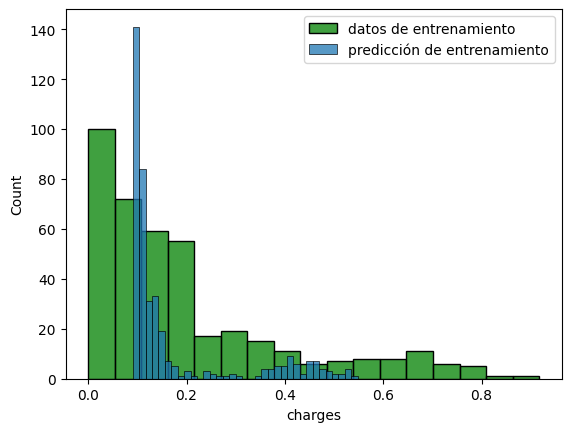

In [76]:
pred_train_8 = modelo_8_final.predict(x_train)
pred_test_8 = modelo_8_final.predict(x_test)
# vamos a desescalar nuestras variables para obtener los valores reales
pred_train_des_8 = pred_train_8 * (np.max(y) - np.min(y)) + np.min(y)
pred_test_des_8 = pred_test_8 * (np.max(y) - np.min(y)) + np.min(y)
y_train_des = y_train * (np.max(y) - np.min(y)) + np.min(y)
y_test_des = y_test * (np.max(y) - np.min(y)) + np.min(y)
r2_train_8 = r2_score(y_train_des, pred_train_des_8)
rmse_train_8 = root_mean_squared_error(y_train_des, pred_train_des_8)
mae_train_8 = mean_absolute_error(y_train_des, pred_train_des_8)
mape_train_8 = mean_absolute_percentage_error(y_train_des, pred_train_des_8)
print(f'Las métricas de desemepeño en entrenamiento para MLP son:\nR4: {r2_train_8}\nRMSE: {rmse_train_8}\nMAE: {mae_train_8}\nMAPE: {mape_train_8}')
sb.histplot(data= y_train_des, x= 'charges',color='green', label='datos de entrenamiento')
sb.histplot(pred_train_des_8, label='predicción de entrenamiento')
plt.legend()
plt.show()

Las métricas de desemepeño en entrenamiento para MLP son:
R4: 0.5198619273491605
RMSE: 0.13264497947304402
MAE: 0.09251038731172341
MAPE: 3.5773745433545274


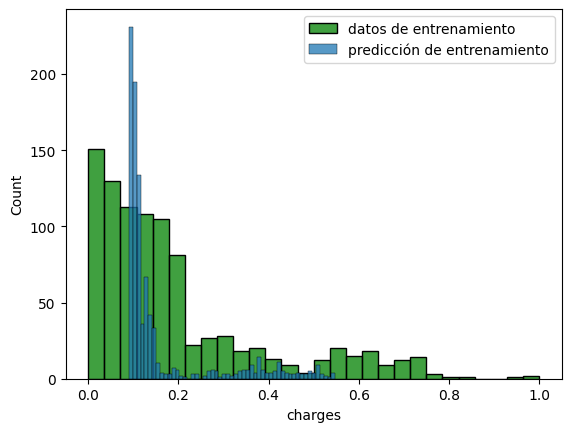

In [77]:
r2_test_8 = r2_score(y_test_des, pred_test_des_8)
rmse_test_8 = root_mean_squared_error(y_test_des, pred_test_des_8)
mae_test_8 = mean_absolute_error(y_test_des, pred_test_des_8)
mape_test_8 = mean_absolute_percentage_error(y_test_des, pred_test_des_8)
print(f'Las métricas de desemepeño en entrenamiento para MLP son:\nR4: {r2_test_8}\nRMSE: {rmse_test_8}\nMAE: {mae_test_8}\nMAPE: {mape_test_8}')
sb.histplot(data= y_test_des, x= 'charges',color='green', label='datos de entrenamiento')
sb.histplot(pred_test_des_8, label='predicción de entrenamiento')
plt.legend()
plt.show()